In [1]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve
)

torch.manual_seed(42)
np.random.seed(42)

In [3]:
ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]

)

ratings["user_id"] -= 1
ratings["movie_id"] -= 1

ratings.head()

,user_id,movie_id,rating,timestamp
0,195,241,3,881250949
1,185,301,3,891717742
2,21,376,1,878887116
3,243,50,2,880606923
4,165,345,1,886397596


In [4]:
train_df, test_df = train_test_split(

    ratings,

    test_size=0.2,

    random_state=42

)

print("Training Samples :", len(train_df))
print("Testing Samples  :", len(test_df))

Training Samples : 80000
Testing Samples  : 20000


In [5]:
train_df["label"] = (

    train_df["rating"] >= 3

).astype(np.float32)

test_df["label"] = (

    test_df["rating"] >= 3

).astype(np.float32)

In [6]:
user_columns = [

    "user_id",

    "age",

    "gender",

    "occupation",

    "zip_code"

]

users = pd.read_csv(

    "../data/u.user",

    sep="|",

    names=user_columns

)

users["user_id"] -= 1

users.head()

,user_id,age,gender,occupation,zip_code
0,0,24,M,technician,85711
1,1,53,F,other,94043
2,2,23,M,writer,32067
3,3,24,M,technician,43537
4,4,33,F,other,15213


In [7]:
gender_to_idx = {

    gender: idx

    for idx, gender in enumerate(

        users["gender"].unique()

    )

}

occupation_to_idx = {

    occupation: idx

    for idx, occupation in enumerate(

        users["occupation"].unique()

    )

}

users["gender_idx"] = users["gender"].map(

    gender_to_idx

)

users["occupation_idx"] = users["occupation"].map(

    occupation_to_idx

)

In [8]:
users["age"] = (

    users["age"] /

    users["age"].max()

)

In [9]:
train_df = train_df.merge(

    users,

    on="user_id"

)

test_df = test_df.merge(

    users,

    on="user_id"

)

In [10]:
movie_columns = [

    "movie_id",

    "title",

    "release_date",

    "video_release_date",

    "IMDb_URL"

]

genre_columns = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]

movie_columns += genre_columns

movies = pd.read_csv(

    "../data/u.item",

    sep="|",

    encoding="latin-1",

    names=movie_columns

)

movies["movie_id"] -= 1

In [11]:
train_df = train_df.merge(

    movies,

    on="movie_id"

)

test_df = test_df.merge(

    movies,

    on="movie_id"

)

In [12]:
train_df.head()

,user_id,movie_id,rating,timestamp,label,age,gender,occupation,zip_code,gender_idx,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,806,1410,1,893082619,0.0,0.561644,F,healthcare,93555,1,...,0,0,0,0,0,0,1,0,0,0
1,473,658,5,887925187,1.0,0.698630,M,executive,93711,0,...,0,0,0,0,1,0,0,1,0,0
2,462,267,4,877384940,1.0,0.657534,F,healthcare,75218,1,...,0,0,0,0,0,1,0,0,0,0
3,138,285,4,879537844,1.0,0.273973,M,student,08904,0,...,0,0,0,0,0,1,0,0,1,0
4,620,750,4,883799651,1.0,0.232877,M,student,60402,0,...,0,0,0,0,0,1,0,1,0,0


# Wide and Deep

In [17]:
train_df["age_group"] = pd.cut(

    train_df["age"],

    bins=[
        0.0,

        0.2,

        0.4,

        0.6,

        0.8,

        1.0

    ],

    labels=[

        0,

        1,

        2,

        3,
        
        4

    ],
    include_lowest=True

).astype(int)


test_df["age_group"] = pd.cut(

    test_df["age"],

    bins=[
0.0,
        0.2,

        0.4,

        0.6,

        0.8,

        1.0

    ],

    labels=[

        0,

        1,

        2,

        3,4

    ],
    include_lowest=True

).astype(int)

In [18]:
genre_columns = [

    "unknown",

    "Action",

    "Adventure",

    "Animation",

    "Children",

    "Comedy",

    "Crime",

    "Documentary",

    "Drama",

    "Fantasy",

    "Film-Noir",

    "Horror",

    "Musical",

    "Mystery",

    "Romance",

    "Sci-Fi",

    "Thriller",

    "War",

    "Western"

]


def get_primary_genre(row):

    for genre in genre_columns:

        if row[genre] == 1:

            return genre

    return "unknown"


train_df["primary_genre"] = train_df.apply(

    get_primary_genre,

    axis=1

)

test_df["primary_genre"] = test_df.apply(

    get_primary_genre,

    axis=1
)

In [19]:
train_df["gender_genre"] = (

    train_df["gender"]

    +

    "_"

    +

    train_df["primary_genre"]

)


test_df["gender_genre"] = (

    test_df["gender"]

    +

    "_"

    +

    test_df["primary_genre"]

)

In [20]:
# Create age groups from the ORIGINAL age values
users["age_group"] = pd.cut(
    users["age"] * users["age"].max(),   # convert back if already normalized
    bins=[0, 18, 25, 35, 50, 100],
    labels=[
        "Teen",
        "YoungAdult",
        "Adult",
        "MiddleAge",
        "Senior"
    ],
    include_lowest=True
)

# Merge again because we added a new column
train_df = train_df.drop(columns=["age_group"], errors="ignore")
test_df = test_df.drop(columns=["age_group"], errors="ignore")

train_df = train_df.merge(
    users[["user_id", "age_group"]],
    on="user_id"
)

test_df = test_df.merge(
    users[["user_id", "age_group"]],
    on="user_id"
)

In [21]:
def get_primary_genre(row):

    for genre in genre_columns:

        if row[genre] == 1:
            return genre

    return "unknown"


train_df["primary_genre"] = train_df.apply(
    get_primary_genre,
    axis=1
)

test_df["primary_genre"] = test_df.apply(
    get_primary_genre,
    axis=1
)

In [22]:
train_df["gender_x_genre"] = (
    train_df["gender"] +
    "_" +
    train_df["primary_genre"]
)

test_df["gender_x_genre"] = (
    test_df["gender"] +
    "_" +
    test_df["primary_genre"]
)

In [23]:
train_df["occupation_x_genre"] = (
    train_df["occupation"] +
    "_" +
    train_df["primary_genre"]
)

test_df["occupation_x_genre"] = (
    test_df["occupation"] +
    "_" +
    test_df["primary_genre"]
)

In [25]:
train_df["age_x_genre"] = (
    train_df["age_group"].astype(str)
    +
    "_"
    +
    train_df["primary_genre"]
)

test_df["age_x_genre"] = (
    test_df["age_group"].astype(str)
    +
    "_"
    +
    test_df["primary_genre"]
)

In [26]:
wide_tokens = pd.concat([

    train_df["gender_x_genre"],

    train_df["occupation_x_genre"],

    train_df["age_x_genre"]

]).unique()

wide_to_idx = {

    token: idx

    for idx, token in enumerate(

        wide_tokens

    )

}

print(

    "Wide Features:",

    len(wide_to_idx)

)

Wide Features: 406


In [29]:
def encode_wide(row):
    return [
        wide_to_idx.get(row["gender_x_genre"], 0),
        wide_to_idx.get(row["occupation_x_genre"], 0),
        wide_to_idx.get(row["age_x_genre"], 0),
    ]

train_df["wide_features"] = train_df.apply(encode_wide, axis=1)
test_df["wide_features"] = test_df.apply(encode_wide, axis=1)



train_df["wide_features"] = train_df.apply(

    encode_wide,

    axis=1

)

test_df["wide_features"] = test_df.apply(

    encode_wide,

    axis=1
)

In [30]:
train_df[[
    "gender_x_genre",
    "occupation_x_genre",
    "age_x_genre",
    "wide_features"
]].head()

,gender_x_genre,occupation_x_genre,age_x_genre,wide_features
0,F_Adventure,healthcare_Adventure,Teen_Adventure,"[0, 37, 387]"
1,M_Comedy,executive_Comedy,Teen_Comedy,"[1, 38, 388]"
2,F_Drama,healthcare_Drama,Teen_Drama,"[2, 39, 389]"
3,M_Drama,student_Drama,Teen_Drama,"[3, 40, 389]"
4,M_Action,student_Action,Teen_Action,"[4, 41, 390]"


In [31]:
class WideDeepDataset(Dataset):

    def __init__(self, dataframe):

        self.user = torch.LongTensor(
            dataframe["user_id"].values
        )

        self.movie = torch.LongTensor(
            dataframe["movie_id"].values
        )

        self.gender = torch.LongTensor(
            dataframe["gender_idx"].values
        )

        self.occupation = torch.LongTensor(
            dataframe["occupation_idx"].values
        )

        self.age = torch.FloatTensor(
            dataframe["age"].values
        )

        self.genres = torch.FloatTensor(
            dataframe[genre_columns].values
        )

        self.wide = dataframe[
            "wide_features"
        ].tolist()

        self.labels = torch.FloatTensor(
            dataframe["label"].values
        )

    def __len__(self):

        return len(self.labels)

    def __getitem__(self, idx):

        return (

            self.user[idx],

            self.movie[idx],

            self.gender[idx],

            self.occupation[idx],

            self.age[idx],

            self.genres[idx],

            torch.LongTensor(
                self.wide[idx]
            ),

            self.labels[idx]

        )

In [32]:
train_dataset = WideDeepDataset(
    train_df
)

test_dataset = WideDeepDataset(
    test_df
)

C:\Users\miyas\AppData\Local\Temp\ipykernel_16616\3838671738.py:5: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  self.user = torch.LongTensor(


In [33]:
train_loader = DataLoader(

    train_dataset,

    batch_size=512,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=512,

    shuffle=False

)

In [34]:
batch = next(iter(train_loader))

for tensor in batch:

    print(tensor.shape)

torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512])
torch.Size([512, 19])
torch.Size([512, 3])
torch.Size([512])


In [35]:
class WideModel(nn.Module):

    def __init__(

        self,

        num_wide_features

    ):

        super().__init__()

        self.embedding = nn.Embedding(

            num_wide_features,

            1

        )

    def forward(

        self,

        wide_features

    ):

        score = self.embedding(

            wide_features

        )

        score = score.sum(

            dim=1

        )

        return score.squeeze()

In [36]:
wide = WideModel(

    len(wide_to_idx)

)

batch = next(
    iter(train_loader)
)

score = wide(

    batch[6]

)

print(score.shape)

torch.Size([512])


In [37]:
class DeepModel(nn.Module):

    def __init__(

        self,

        num_users,

        num_movies,

        num_genders,

        num_occupations

    ):

        super().__init__()

        self.encoder = FeatureEncoder(

            num_users,

            num_movies,

            num_genders,

            num_occupations

        )

        self.network = nn.Sequential(

            nn.Linear(64,128),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(128,64),

            nn.ReLU(),

            nn.Dropout(0.2),

            nn.Linear(64,1)

        )

    def forward(

        self,

        user,

        movie,

        gender,

        occupation,

        age,

        genres

    ):

        features = self.encoder(

            user,

            movie,

            gender,

            occupation,

            age,

            genres

        )

        return self.network(
            features
        ).squeeze()

In [42]:
class FeatureEncoder(nn.Module):
    """
    Embeds categorical features (user, movie, gender, occupation),
    keeps continuous / multi-hot features (age, genres) as-is,
    concatenates them, and projects to a 64-dim vector.
    """
    def __init__(
        self,
        num_users,
        num_movies,
        num_genders,
        num_occupations,
    ):
        super().__init__()

        self.user_embedding = nn.Embedding(num_users, 32)
        self.movie_embedding = nn.Embedding(num_movies, 32)
        self.gender_embedding = nn.Embedding(num_genders, 4)
        self.occupation_embedding = nn.Embedding(
            num_occupations, 8
        )

        # 32 + 32 + 4 + 8 + 1 (age) + 19 (genres) = 96
        self.projection = nn.Linear(96, 64)

    def forward(self, user, movie, gender, occupation, age, genres):
        u = self.user_embedding(user)      # (B, 32)
        m = self.movie_embedding(movie)    # (B, 32)
        g = self.gender_embedding(gender)  # (B, 4)
        o = self.occupation_embedding(occupation)  # (B, 8)
        a = age.unsqueeze(1)               # (B, 1)

        x = torch.cat(
            [u, m, g, o, a, genres],
            dim=1,
        )                                  # (B, 96)

        return self.projection(x)          # (B, 64)


In [43]:
class WideAndDeep(nn.Module):

    def __init__(

        self,

        num_users,

        num_movies,

        num_genders,

        num_occupations,

        num_wide_features

    ):

        super().__init__()

        self.wide = WideModel(

            num_wide_features

        )

        self.deep = DeepModel(

            num_users,

            num_movies,

            num_genders,

            num_occupations

        )

    def forward(

        self,

        user,

        movie,

        gender,

        occupation,

        age,

        genres,

        wide_features

    ):

        wide_score = self.wide(

            wide_features

        )

        deep_score = self.deep(

            user,

            movie,

            gender,

            occupation,

            age,

            genres

        )

        return wide_score + deep_score

In [44]:
num_users = ratings["user_id"].nunique()

num_movies = ratings["movie_id"].nunique()

model = WideAndDeep(

    num_users=num_users,

    num_movies=num_movies,

    num_genders=len(gender_to_idx),

    num_occupations=len(occupation_to_idx),

    num_wide_features=len(wide_to_idx)

)

In [45]:
batch = next(

    iter(train_loader)

)

output = model(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5],

    batch[6]

)

print(output.shape)

torch.Size([512])


In [46]:
criterion = nn.BCEWithLogitsLoss()
optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [47]:
batch = next(

    iter(train_loader)

)

optimizer.zero_grad()

outputs = model(

    batch[0],

    batch[1],

    batch[2],

    batch[3],

    batch[4],

    batch[5],

    batch[6]

)

loss = criterion(

    outputs,

    batch[7]

)

loss.backward()

optimizer.step()

print(loss.item())

0.7126938104629517


In [48]:
def train_model(

    model,

    train_loader,

    criterion,

    optimizer,

    epochs=20

):

    print("Training Wide & Deep Model...")

    history = []

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0

        for (

            user,

            movie,

            gender,

            occupation,

            age,

            genres,

            wide,

            labels

        ) in train_loader:

            optimizer.zero_grad()

            outputs = model(

                user,

                movie,

                gender,

                occupation,

                age,

                genres,

                wide

            )

            loss = criterion(

                outputs,

                labels

            )

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)

        history.append(epoch_loss)

        print(

            f"Epoch {epoch+1:2d}/{epochs}"

            f" | Loss = {epoch_loss:.4f}"

        )

    return history

In [49]:
history = train_model(

    model,

    train_loader,

    criterion,

    optimizer,

    epochs=20

)

Training Wide & Deep Model...
Epoch  1/20 | Loss = 0.5488
Epoch  2/20 | Loss = 0.4728
Epoch  3/20 | Loss = 0.4383
Epoch  4/20 | Loss = 0.4168
Epoch  5/20 | Loss = 0.4020
Epoch  6/20 | Loss = 0.3911
Epoch  7/20 | Loss = 0.3812
Epoch  8/20 | Loss = 0.3721
Epoch  9/20 | Loss = 0.3661
Epoch 10/20 | Loss = 0.3595
Epoch 11/20 | Loss = 0.3543
Epoch 12/20 | Loss = 0.3489
Epoch 13/20 | Loss = 0.3442
Epoch 14/20 | Loss = 0.3402
Epoch 15/20 | Loss = 0.3367
Epoch 16/20 | Loss = 0.3321
Epoch 17/20 | Loss = 0.3273
Epoch 18/20 | Loss = 0.3249
Epoch 19/20 | Loss = 0.3205
Epoch 20/20 | Loss = 0.3182


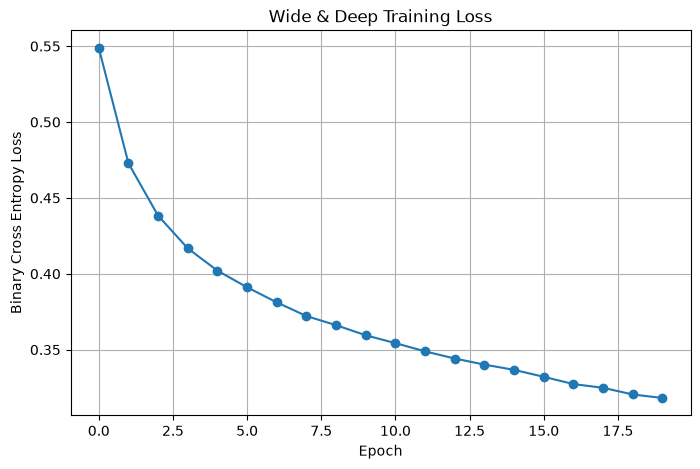

In [50]:
plt.figure(figsize=(8,5))

plt.plot(

    history,

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Binary Cross Entropy Loss")

plt.title("Wide & Deep Training Loss")

plt.grid(True)

plt.show()

In [51]:
def evaluate_model(

    model,

    test_loader

):

    model.eval()

    predictions = []

    probabilities = []

    labels = []

    with torch.no_grad():

        for (

            user,

            movie,

            gender,

            occupation,

            age,

            genres,

            wide,

            target

        ) in test_loader:

            logits = model(

                user,

                movie,

                gender,

                occupation,

                age,

                genres,

                wide

            )

            probs = torch.sigmoid(

                logits

            )

            preds = (

                probs >= 0.5

            ).float()

            probabilities.extend(

                probs.cpu().numpy()

            )

            predictions.extend(

                preds.cpu().numpy()

            )

            labels.extend(

                target.cpu().numpy()

            )

    accuracy = accuracy_score(

        labels,

        predictions

    )

    auc = roc_auc_score(

        labels,

        probabilities

    )

    return (

        accuracy,

        auc,

        np.array(probabilities),

        np.array(predictions),

        np.array(labels)

    )

In [52]:
accuracy, auc, probabilities, predictions, labels = evaluate_model(

    model,

    test_loader

)

print(

    f"Accuracy : {accuracy:.4f}"

)

print(

    f"AUC : {auc:.4f}"

)

Accuracy : 0.8334
AUC : 0.7763


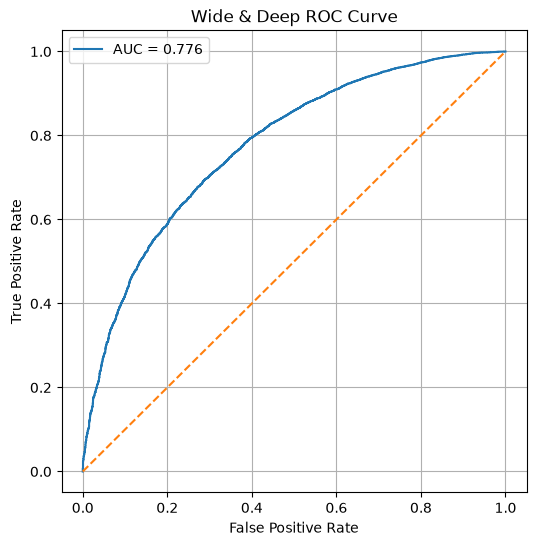

In [53]:
fpr, tpr, _ = roc_curve(

    labels,

    probabilities

)

plt.figure(figsize=(6,6))

plt.plot(

    fpr,

    tpr,

    label=f"AUC = {auc:.3f}"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Wide & Deep ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [54]:
def precision_at_k(

    prediction_df,

    k=10

):

    precisions = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        precisions.append(

            top_k["label"].mean()

        )

    return np.mean(

        precisions

    )

In [55]:
def recall_at_k(

    prediction_df,

    k=10

):

    recalls = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        relevant = group["label"].sum()

        if relevant == 0:

            continue

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits = top_k["label"].sum()

        recalls.append(

            hits / relevant

        )

    return np.mean(

        recalls

    )

In [56]:
def hit_rate_at_k(

    prediction_df,

    k=10

):

    hits = []

    grouped = prediction_df.groupby(

        "user_id"

    )

    for _, group in grouped:

        top_k = group.sort_values(

            "probability",

            ascending=False

        ).head(k)

        hits.append(

            top_k["label"].sum() > 0

        )

    return np.mean(

        hits

    )

In [59]:
prediction_df = pd.DataFrame({
    "user_id":    test_df["user_id"].values,
    "movie_id":   test_df["movie_id"].values,
    "label":      labels,
    "probability": probabilities,
    "prediction": predictions,
})


In [60]:
p10 = precision_at_k(

    prediction_df,

    k=10

)

r10 = recall_at_k(

    prediction_df,

    k=10

)

hr10 = hit_rate_at_k(

    prediction_df,

    k=10

)

metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "AUC",

        "Precision@10",

        "Recall@10",

        "HitRate@10"

    ],

    "Value":[

        accuracy,

        auc,

        p10,

        r10,

        hr10

    ]

})

metrics

,Metric,Value
0,Accuracy,0.833400
1,AUC,0.776339
2,Precision@10,0.883094
3,Recall@10,0.688594
4,HitRate@10,0.995745


In [62]:
prediction_df[

    [

        "user_id",

        "movie_id",

        "label",

        "probability",

        "prediction"

    ]

].sample(20)

,user_id,movie_id,label,probability,prediction
10650,693,203,1.0,0.999602,1.0
2041,192,681,0.0,0.787745,1.0
8668,222,322,0.0,0.384715,0.0
1114,57,602,1.0,0.999475,1.0
13902,497,424,0.0,0.653290,1.0
11963,898,203,1.0,0.978156,1.0
11072,372,205,1.0,0.752746,1.0
3002,773,825,0.0,0.060066,0.0
19771,606,120,0.0,0.982843,1.0
8115,129,443,1.0,0.896327,1.0
